In [ ]:
# # ===== 1. LOAD & EXPLORE DATASET =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Load dataset
import pandas as pd

df = pd.read_csv('/loan_prediction_dataset.csv')

df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [ ]:
import pandas as pd
df = pd.read_csv('/loan_prediction_dataset.csv')
df.head()
df.tail()
df.shape

(2000, 7)

In [ ]:
df.tail()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
1995,63,87580,761,29716,48,Employed,1
1996,67,27368,695,13601,36,Employed,0
1997,69,105436,636,37018,36,Self-Employed,0
1998,24,116136,441,9061,48,Employed,0
1999,20,66403,616,9609,12,Unemployed,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [ ]:
print("\n# Columns:", df.columns.tolist())
print("\n# Dataset Info:")
print(df.info())
print("\n# Target Distribution:")
print(df['Loan_Approved'].value_counts(normalize=True))
print("\n# Missing Values:")
print(df.isnull().sum())


# Columns: ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status', 'Loan_Approved']

# Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None

# Target Distribution:
Loan_Approved
0    0.829
1    0.171
Name: proportion, dtype: float64

# Missing Values:
Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

In [ ]:
# # ===== 2. DATA CLEANING & PREPROCESSING =====
# Handle missing values (if any - fill with mode/mean)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

In [ ]:
# Encode categorical features
le = LabelEncoder()
df['Employment_Status'] = le.fit_transform(df['Employment_Status'])


In [ ]:
# Features and target
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [ ]:
# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n# Preprocessing Complete. Shape after scaling:", X_scaled.shape)


# Preprocessing Complete. Shape after scaling: (2000, 6)


In [ ]:
# Handle class imbalance using SMOTE (optional - check if needed)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print("# After SMOTE:", y_resampled.value_counts(normalize=True))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# After SMOTE: Loan_Approved
0    0.5
1    0.5
Name: proportion, dtype: float64


Text(0.5, 0.98, '# EDA: Loan Approval Insights')

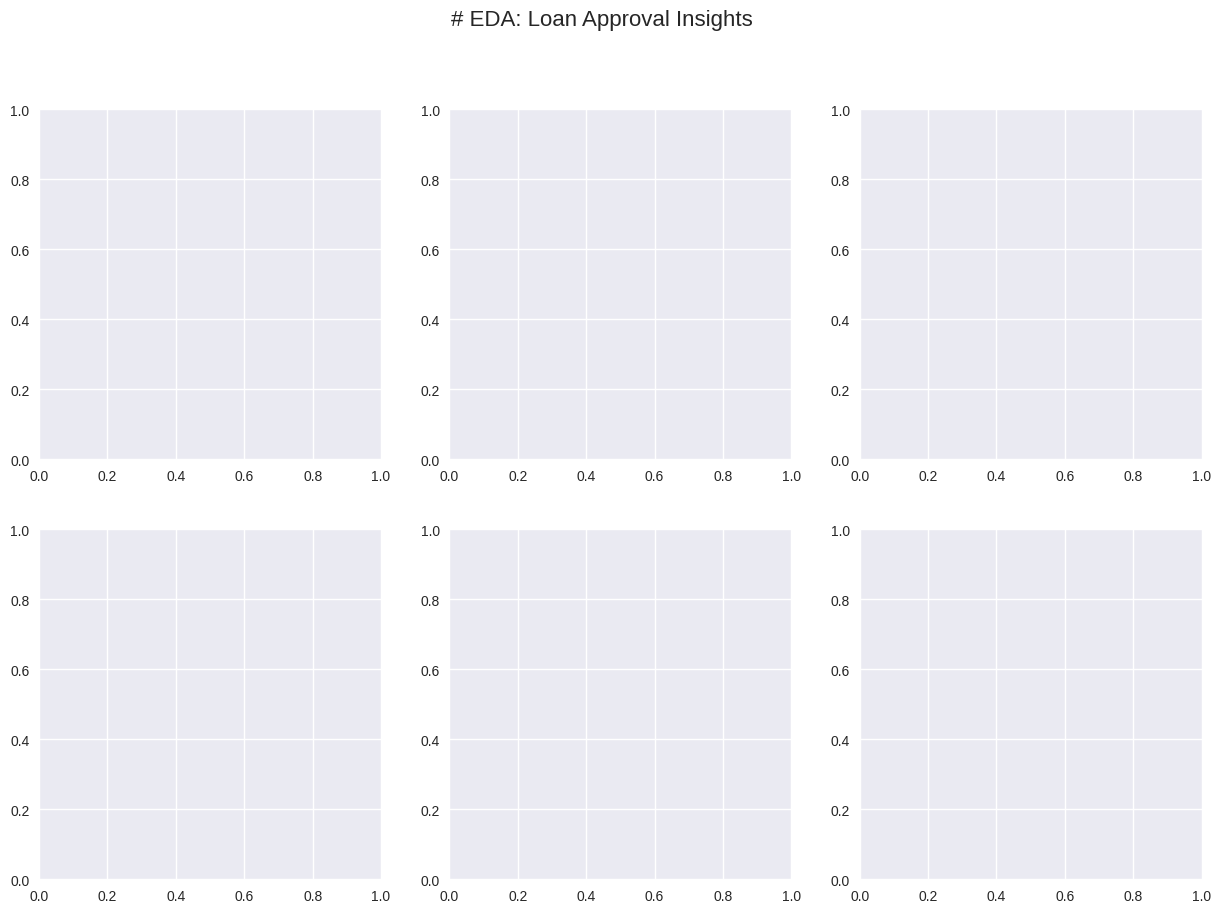

In [ ]:
# # ===== 3. EXPLORATORY DATA ANALYSIS (EDA) =====
# Set style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('# EDA: Loan Approval Insights', fontsize=16)


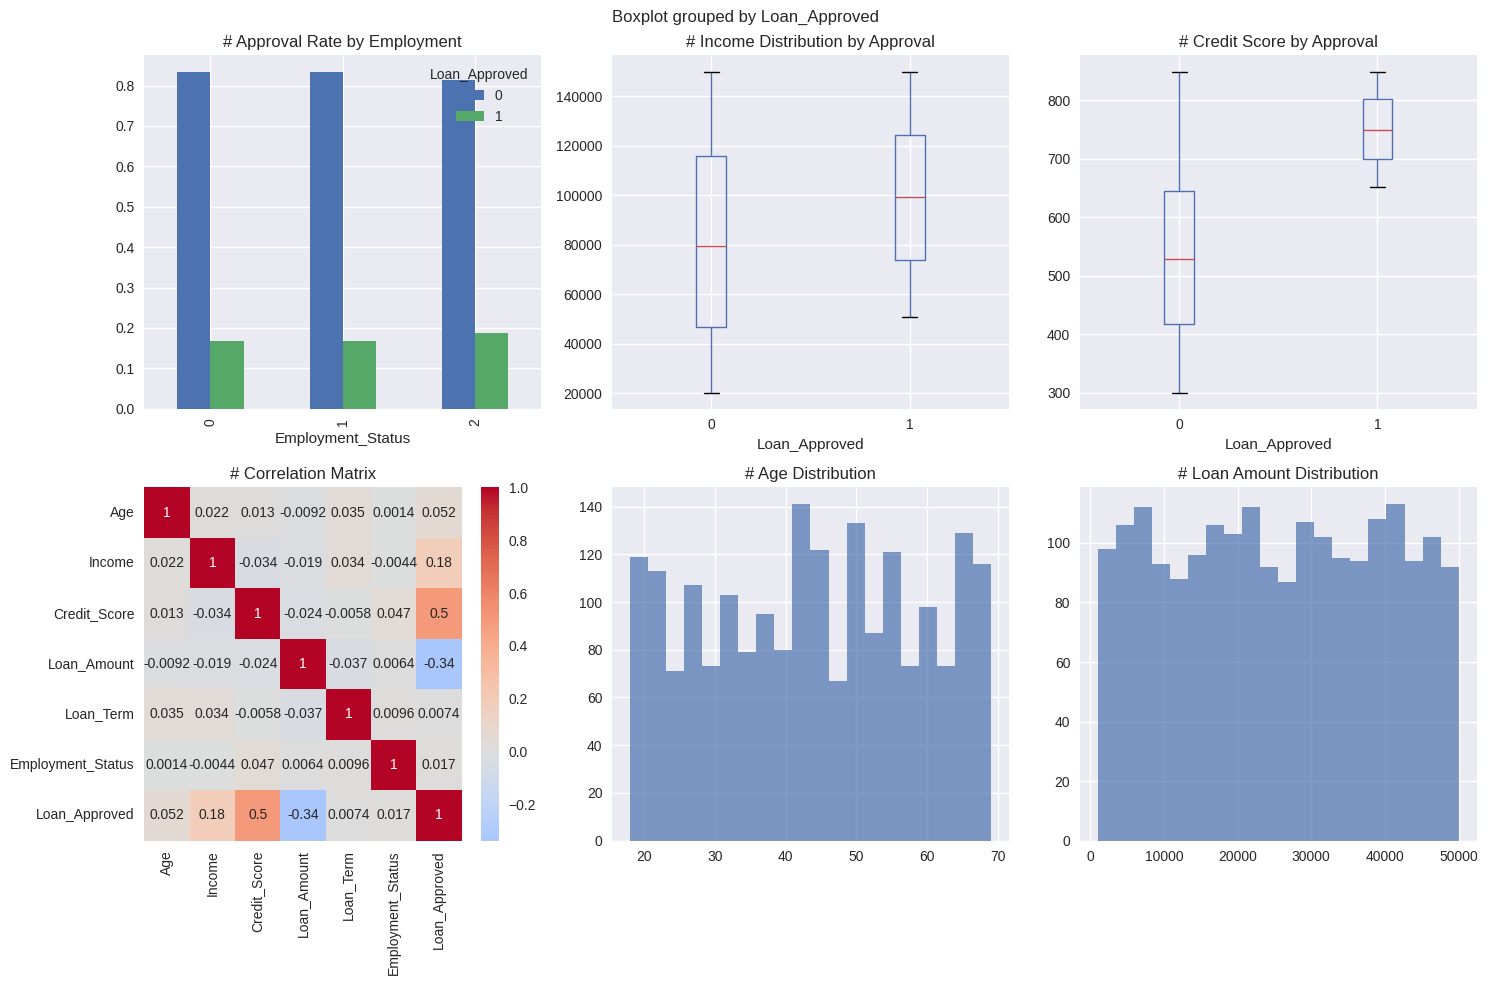

In [ ]:
# # ===== 3. EXPLORATORY DATA ANALYSIS (EDA) =====
# Set style
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('# EDA: Loan Approval Insights', fontsize=16)

# Approval rates by Employment Status
employment_rates = pd.crosstab(df['Employment_Status'], df['Loan_Approved'], normalize='index')
employment_rates.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('# Approval Rate by Employment')
axes[0,0].legend(title='Loan_Approved')

# Income vs Approval (boxplot)
df.boxplot(column='Income', by='Loan_Approved', ax=axes[0,1])
axes[0,1].set_title('# Income Distribution by Approval')

# Credit Score vs Approval
df.boxplot(column='Credit_Score', by='Loan_Approved', ax=axes[0,2])
axes[0,2].set_title('# Credit Score by Approval')

# Correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1,0])
axes[1,0].set_title('# Correlation Matrix')

# Age distribution
df['Age'].hist(bins=20, ax=axes[1,1], alpha=0.7)
axes[1,1].set_title('# Age Distribution')

# Loan Amount distribution
df['Loan_Amount'].hist(bins=20, ax=axes[1,2], alpha=0.7)
axes[1,2].set_title('# Loan Amount Distribution')

plt.tight_layout()
plt.show()

In [ ]:
# # ===== 4. MODEL BUILDING & TRAINING =====
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"\n# Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob



# Training Logistic Regression...

# Training Decision Tree...

# Training Random Forest...

# Training SVM...


In [ ]:
# # ===== 5. MODEL EVALUATION =====
results = []

for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': auc
    })


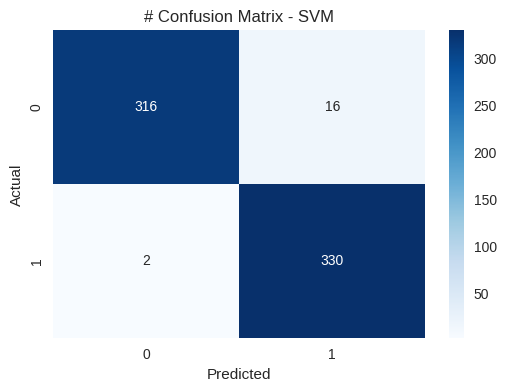

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'# Confusion Matrix - {name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


# MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8961     0.8768  0.9217    0.8987   0.9698
      Decision Tree    0.9985     1.0000  0.9970    0.9985   0.9985
      Random Forest    0.9985     1.0000  0.9970    0.9985   1.0000
                SVM    0.9729     0.9538  0.9940    0.9735   0.9987


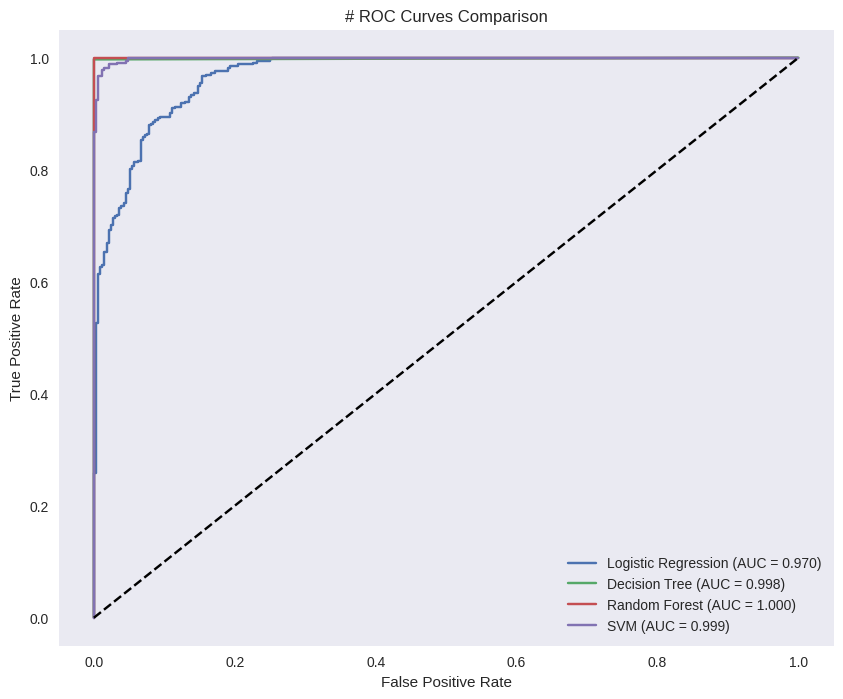

In [ ]:
# Results table
results_df = pd.DataFrame(results)
print("\n# MODEL PERFORMANCE COMPARISON")
print(results_df.round(4).to_string(index=False))

# ROC Curves
plt.figure(figsize=(10,8))
for name in models:
    y_prob = probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('# ROC Curves Comparison')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# # ===== 6. MODEL COMPARISON & BEST MODEL =====
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1 = results_df['F1-Score'].max()

print(f"\n# 🏆 BEST MODEL: {best_model_name}")
print(f"# Best F1-Score: {best_f1:.4f}")
print(f"\n# Why {best_model_name} is best:")
if best_model_name == 'Random Forest':
    print("- Handles non-linear relationships effectively")
    print("- Ensemble method reduces overfitting")
    print("- Robust to outliers and feature interactions")
elif best_model_name == 'Logistic Regression':
    print("- Simple, interpretable probabilities")
    print("- Performs well with linearly separable data")
else:
    print("- Balances bias-variance tradeoff optimally")



# 🏆 BEST MODEL: Decision Tree
# Best F1-Score: 0.9985

# Why Decision Tree is best:
- Balances bias-variance tradeoff optimally


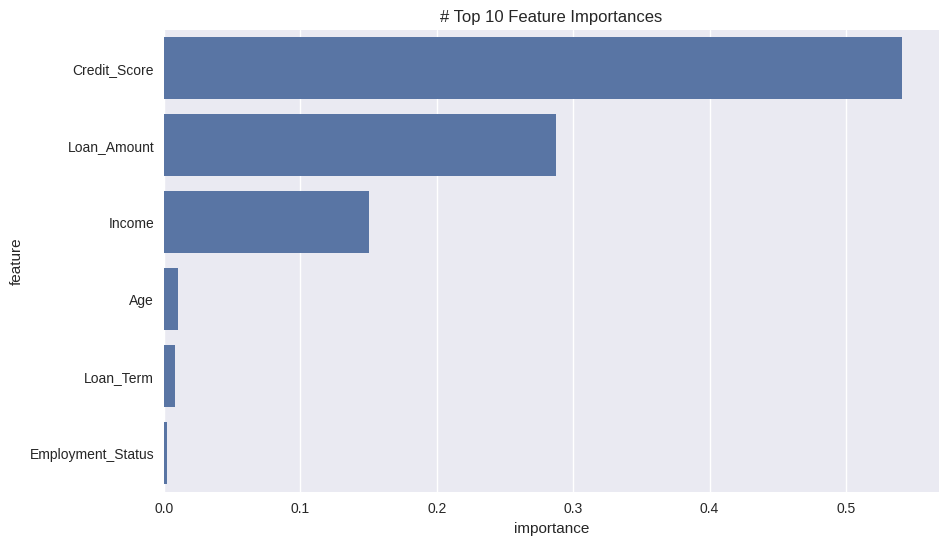


# Top Features:
        feature  importance
2  Credit_Score    0.541029
3   Loan_Amount    0.287117
1        Income    0.150571
0           Age    0.010544
4     Loan_Term    0.008254

# 🎯 BANK USAGE IN PRACTICE:
1. Input customer data (Age, Income, CreditScore, etc.)
2. Model predicts approval probability
3. Set threshold (e.g., 0.6) for risk management
4. High-risk cases → manual review
5. Monitor model performance quarterly
6. Retrain with new data annually


In [ ]:
# Feature importance (for tree-based models)
if 'Random Forest' in trained_models or 'Decision Tree' in trained_models:
    rf_model = trained_models.get('Random Forest', trained_models['Decision Tree'])
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
    plt.title('# Top 10 Feature Importances')
    plt.show()
    print("\n# Top Features:")
    print(feature_importance.head())

print("\n# 🎯 BANK USAGE IN PRACTICE:")
print("1. Input customer data (Age, Income, CreditScore, etc.)")
print("2. Model predicts approval probability")
print("3. Set threshold (e.g., 0.6) for risk management")
print("4. High-risk cases → manual review")
print("5. Monitor model performance quarterly")
print("6. Retrain with new data annually")
